# 01 — Answer Corpus

This notebook builds the evaluation corpus: 50 (question, context, answer) instances drawn from
the NordFinance dataset, covering three pipeline types and three question types.

**Outputs produced:**
- `data/answers/vector_answers.json` — VectorRAG answers
- `data/answers/graph_answers.json` — GraphRAG answers
- `data/answers/handcrafted_answers.json` — 10 hand-crafted quality-level answers
- `data/human/human_scores.csv` — synthetic human baseline scores

> **Note:** In production, replace the synthetic data cells with a loader that reads
> the cached outputs from [Dima806/graphrag_vs_vectorrag](https://github.com/Dima806/graphrag_vs_vectorrag).
> The synthetic data is included so that notebooks 02–05 can run end-to-end in a fresh Codespace.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import random

import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)
print(f"Project root: {ROOT}")

FIGURES_DIR = ROOT / "outputs" / "figures"
RESULTS_DIR = ROOT / "outputs" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Project root: /workspaces/llm_judge_benchmark


## 1. Synthetic NordFinance corpus

Twenty NordBank questions with VectorRAG and GraphRAG answers (40 instances),
plus 10 hand-crafted answers at three quality levels (good / mediocre / bad).
Total: **50 unique evaluation instances**.

In [2]:
QUESTIONS = [
    {"qid": "q01", "question": "What was NordBank's Tier 1 capital ratio in 2024?",
     "context": ["NordBank reported a Tier 1 capital ratio of 18.4% in its 2024 annual report, exceeding the regulatory minimum of 12%."],
     "answer_good": "NordBank's Tier 1 capital ratio was 18.4% in 2024.",
     "question_type": "single_hop"},
    {"qid": "q02", "question": "How did NordBank's net interest margin change between 2022 and 2024?",
     "context": ["Net interest margin was 2.1% in 2022.", "By 2024 NordBank reported a net interest margin of 2.7%, driven by rising policy rates."],
     "answer_good": "NordBank's net interest margin increased from 2.1% in 2022 to 2.7% in 2024.",
     "question_type": "multi_hop"},
    {"qid": "q03", "question": "Did NordBank receive any regulatory fines in 2023?",
     "context": ["NordBank's 2023 compliance report highlights updated AML procedures and staff training investments."],
     "answer_good": "The context does not mention any regulatory fines in 2023.",
     "question_type": "absence_reasoning"},
    {"qid": "q04", "question": "What is NordBank's primary retail lending product?",
     "context": ["NordBank's retail division offers mortgage loans, personal loans, and credit cards. Mortgage loans account for 68% of the retail loan book."],
     "answer_good": "NordBank's primary retail lending product is mortgage loans, which make up 68% of its retail loan book.",
     "question_type": "single_hop"},
    {"qid": "q05", "question": "How many employees did NordBank have at the end of 2024?",
     "context": ["As of December 31 2024, NordBank employed 12,450 full-time equivalents, down from 13,100 in 2023 following a restructuring programme."],
     "answer_good": "NordBank had 12,450 full-time equivalent employees at the end of 2024.",
     "question_type": "single_hop"},
    {"qid": "q06", "question": "What caused the reduction in NordBank's cost-to-income ratio from 2022 to 2024?",
     "context": ["Cost-to-income ratio fell from 61% in 2022 to 54% in 2024.", "The improvement was attributed to the digital transformation programme launched in Q3 2022, which automated back-office processes."],
     "answer_good": "The reduction in NordBank's cost-to-income ratio from 61% to 54% was driven by the digital transformation programme that automated back-office processes.",
     "question_type": "multi_hop"},
    {"qid": "q07", "question": "Has NordBank expanded into any new markets since 2022?",
     "context": ["NordBank's 2024 strategy update focuses on deepening penetration in existing Nordic markets."],
     "answer_good": "The context does not indicate expansion into new markets; NordBank's strategy focuses on existing Nordic markets.",
     "question_type": "absence_reasoning"},
    {"qid": "q08", "question": "What was NordBank's return on equity in 2024?",
     "context": ["NordBank achieved a return on equity of 14.2% in 2024, compared to 11.8% in 2023."],
     "answer_good": "NordBank's return on equity was 14.2% in 2024.",
     "question_type": "single_hop"},
    {"qid": "q09", "question": "What rating did Moody's assign to NordBank's long-term debt?",
     "context": ["Moody's affirmed NordBank's long-term issuer rating at A2 with a stable outlook in June 2024."],
     "answer_good": "Moody's assigned NordBank's long-term debt an A2 rating with a stable outlook.",
     "question_type": "single_hop"},
    {"qid": "q10", "question": "How does NordBank's NPL ratio compare to the Nordic banking sector average?",
     "context": ["NordBank's non-performing loan ratio stands at 1.2%.", "The Nordic banking sector average NPL ratio was 1.8% in 2024 according to the ECB."],
     "answer_good": "NordBank's NPL ratio of 1.2% is below the Nordic banking sector average of 1.8%.",
     "question_type": "multi_hop"},
    {"qid": "q11", "question": "What sustainability targets has NordBank committed to?",
     "context": ["NordBank's 2024 ESG report details its commitment to net-zero financed emissions by 2050 and a 50% reduction in operational carbon by 2030."],
     "answer_good": "NordBank has committed to net-zero financed emissions by 2050 and a 50% reduction in operational carbon by 2030.",
     "question_type": "single_hop"},
    {"qid": "q12", "question": "Did NordBank pay a dividend in 2023?",
     "context": ["NordBank's board proposed a dividend of EUR 1.20 per share for 2023, subject to shareholder approval at the AGM."],
     "answer_good": "NordBank proposed a dividend of EUR 1.20 per share for 2023.",
     "question_type": "single_hop"},
    {"qid": "q13", "question": "What is the relationship between NordBank's loan growth and deposit growth?",
     "context": ["Customer deposits grew 8% year-on-year to EUR 142 billion.", "Net loans to customers grew 5% to EUR 118 billion."],
     "answer_good": "NordBank's deposit growth (8%) outpaced loan growth (5%), improving its loan-to-deposit ratio.",
     "question_type": "multi_hop"},
    {"qid": "q14", "question": "Has NordBank issued any green bonds?",
     "context": ["NordBank's funding strategy prioritises covered bond issuance and senior preferred notes."],
     "answer_good": "The context does not mention green bond issuance by NordBank.",
     "question_type": "absence_reasoning"},
    {"qid": "q15", "question": "What was NordBank's operating profit in 2024?",
     "context": ["NordBank reported operating profit of EUR 2.3 billion for the full year 2024, a 19% increase from 2023."],
     "answer_good": "NordBank's operating profit was EUR 2.3 billion in 2024, up 19% from 2023.",
     "question_type": "single_hop"},
    {"qid": "q16", "question": "Which business segment contributed most to NordBank's revenue in 2024?",
     "context": ["Corporate banking generated EUR 3.1 billion in revenue.", "Retail banking contributed EUR 2.8 billion.", "Asset management added EUR 0.9 billion."],
     "answer_good": "Corporate banking was NordBank's largest revenue segment at EUR 3.1 billion in 2024.",
     "question_type": "multi_hop"},
    {"qid": "q17", "question": "Is NordBank subject to DORA compliance requirements?",
     "context": ["NordBank's 2024 risk report covers market risk, credit risk, operational risk, and liquidity risk frameworks."],
     "answer_good": "The context does not mention DORA compliance specifically.",
     "question_type": "absence_reasoning"},
    {"qid": "q18", "question": "What was NordBank's liquidity coverage ratio at year-end 2024?",
     "context": ["NordBank's liquidity coverage ratio was 158% as of December 2024, well above the 100% regulatory requirement."],
     "answer_good": "NordBank's liquidity coverage ratio was 158% at year-end 2024.",
     "question_type": "single_hop"},
    {"qid": "q19", "question": "How did rising interest rates affect NordBank's funding costs?",
     "context": ["Wholesale funding costs rose by 85 basis points in 2023.", "This was partially offset by repricing of variable-rate assets, resulting in a net positive interest income effect."],
     "answer_good": "Rising interest rates increased NordBank's wholesale funding costs by 85 bps, but the net effect on interest income was positive due to variable-rate asset repricing.",
     "question_type": "multi_hop"},
    {"qid": "q20", "question": "What cybersecurity incidents did NordBank experience in 2024?",
     "context": ["NordBank invested EUR 120 million in IT security upgrades in 2024 and completed its SOC 2 Type II certification."],
     "answer_good": "The context does not report any cybersecurity incidents; it describes investment in security upgrades.",
     "question_type": "absence_reasoning"},
]

print(f"Questions loaded: {len(QUESTIONS)}")
pd.DataFrame(QUESTIONS)[["qid", "question_type", "question"]].head(10)

Questions loaded: 20


,qid,question_type,question
0,q01,single_hop,What was NordBank's Tier 1 capital ratio in 2024?
1,q02,multi_hop,How did NordBank's net interest margin change ...
2,q03,absence_reasoning,Did NordBank receive any regulatory fines in 2...
3,q04,single_hop,What is NordBank's primary retail lending prod...
4,q05,single_hop,How many employees did NordBank have at the en...
5,q06,multi_hop,What caused the reduction in NordBank's cost-t...
6,q07,absence_reasoning,Has NordBank expanded into any new markets sin...
7,q08,single_hop,What was NordBank's return on equity in 2024?
8,q09,single_hop,What rating did Moody's assign to NordBank's l...
9,q10,multi_hop,How does NordBank's NPL ratio compare to the N...


In [3]:
def make_vector_answer(q: dict) -> str:
    """Simulate a VectorRAG answer: mostly correct but occasionally adds minor noise."""
    good = q["answer_good"]
    if q["question_type"] == "absence_reasoning":
        # Vector retrieval often returns tangential context and hallucinates
        return good.replace("does not", "may").replace("The context does not mention", "Based on the available information,")
    return good


def make_graph_answer(q: dict) -> str:
    """Simulate a GraphRAG answer: better multi-hop reasoning, similar on single-hop."""
    return q["answer_good"]


vector_answers = []
graph_answers = []

for q in QUESTIONS:
    vector_answers.append({
        "id": f"{q['qid']}_vector",
        "question": q["question"],
        "context": q["context"],
        "answer": make_vector_answer(q),
        "pipeline": "vector",
        "question_type": q["question_type"],
    })
    graph_answers.append({
        "id": f"{q['qid']}_graph",
        "question": q["question"],
        "context": q["context"],
        "answer": make_graph_answer(q),
        "pipeline": "graph",
        "question_type": q["question_type"],
    })

print(f"Vector answers: {len(vector_answers)}")
print(f"Graph answers:  {len(graph_answers)}")

Vector answers: 20
Graph answers:  20


In [4]:
HANDCRAFTED = [
    {"id": "hc01_good",
     "question": "What is NordBank's CET1 ratio?",
     "context": ["NordBank's Common Equity Tier 1 ratio was 16.1% as of Q4 2024."],
     "answer": "NordBank's CET1 ratio was 16.1% as of Q4 2024.",
     "pipeline": "handcrafted", "question_type": "single_hop"},
    {"id": "hc01_mediocre",
     "question": "What is NordBank's CET1 ratio?",
     "context": ["NordBank's Common Equity Tier 1 ratio was 16.1% as of Q4 2024."],
     "answer": "NordBank has a strong capital position with a CET1 ratio above 15%.",
     "pipeline": "handcrafted", "question_type": "single_hop"},
    {"id": "hc01_bad",
     "question": "What is NordBank's CET1 ratio?",
     "context": ["NordBank's Common Equity Tier 1 ratio was 16.1% as of Q4 2024."],
     "answer": "NordBank's CET1 ratio was 12.5%, meeting the minimum regulatory requirement.",
     "pipeline": "handcrafted", "question_type": "single_hop"},
    {"id": "hc02_good",
     "question": "What drove NordBank's fee income growth?",
     "context": ["Fee income grew 12% in 2024.", "Growth was driven by wealth management mandates and increased transaction volumes in trade finance."],
     "answer": "NordBank's fee income grew 12% in 2024, driven by wealth management mandates and higher trade finance volumes.",
     "pipeline": "handcrafted", "question_type": "multi_hop"},
    {"id": "hc02_mediocre",
     "question": "What drove NordBank's fee income growth?",
     "context": ["Fee income grew 12% in 2024.", "Growth was driven by wealth management mandates and increased transaction volumes in trade finance."],
     "answer": "NordBank's fee income grew due to better business conditions.",
     "pipeline": "handcrafted", "question_type": "multi_hop"},
    {"id": "hc02_bad",
     "question": "What drove NordBank's fee income growth?",
     "context": ["Fee income grew 12% in 2024.", "Growth was driven by wealth management mandates and increased transaction volumes in trade finance."],
     "answer": "Fee income declined due to competition from fintech companies.",
     "pipeline": "handcrafted", "question_type": "multi_hop"},
    {"id": "hc03_good",
     "question": "Has NordBank acquired any companies in 2024?",
     "context": ["NordBank's M&A strategy focuses on organic growth and selective bolt-on acquisitions in fintech."],
     "answer": "The context does not confirm any completed acquisitions in 2024; NordBank's strategy mentions selective fintech acquisitions as a goal.",
     "pipeline": "handcrafted", "question_type": "absence_reasoning"},
    {"id": "hc03_mediocre",
     "question": "Has NordBank acquired any companies in 2024?",
     "context": ["NordBank's M&A strategy focuses on organic growth and selective bolt-on acquisitions in fintech."],
     "answer": "NordBank is considering acquisitions in fintech.",
     "pipeline": "handcrafted", "question_type": "absence_reasoning"},
    {"id": "hc03_bad",
     "question": "Has NordBank acquired any companies in 2024?",
     "context": ["NordBank's M&A strategy focuses on organic growth and selective bolt-on acquisitions in fintech."],
     "answer": "Yes, NordBank acquired two fintech companies in 2024.",
     "pipeline": "handcrafted", "question_type": "absence_reasoning"},
    {"id": "hc04_good",
     "question": "What is NordBank's net stable funding ratio?",
     "context": ["NordBank's NSFR was 118% at year-end 2024, comfortably above the 100% minimum."],
     "answer": "NordBank's net stable funding ratio was 118% at year-end 2024.",
     "pipeline": "handcrafted", "question_type": "single_hop"},
]

print(f"Handcrafted answers: {len(HANDCRAFTED)}")
total = len(vector_answers) + len(graph_answers) + len(HANDCRAFTED)
print(f"Total corpus size:   {total}")

Handcrafted answers: 10
Total corpus size:   50


In [5]:
(ROOT / "data" / "answers").mkdir(parents=True, exist_ok=True)

(ROOT / "data" / "answers" / "vector_answers.json").write_text(
    json.dumps(vector_answers, indent=2)
)
(ROOT / "data" / "answers" / "graph_answers.json").write_text(
    json.dumps(graph_answers, indent=2)
)
(ROOT / "data" / "answers" / "handcrafted_answers.json").write_text(
    json.dumps(HANDCRAFTED, indent=2)
)

print("Saved:")
for p in sorted((ROOT / "data" / "answers").glob("*.json")):
    instances = json.loads(p.read_text())
    print(f"  {p.name}: {len(instances)} instances")

Saved:
  graph_answers.json: 20 instances
  handcrafted_answers.json: 10 instances
  vector_answers.json: 20 instances


## 2. Corpus distribution

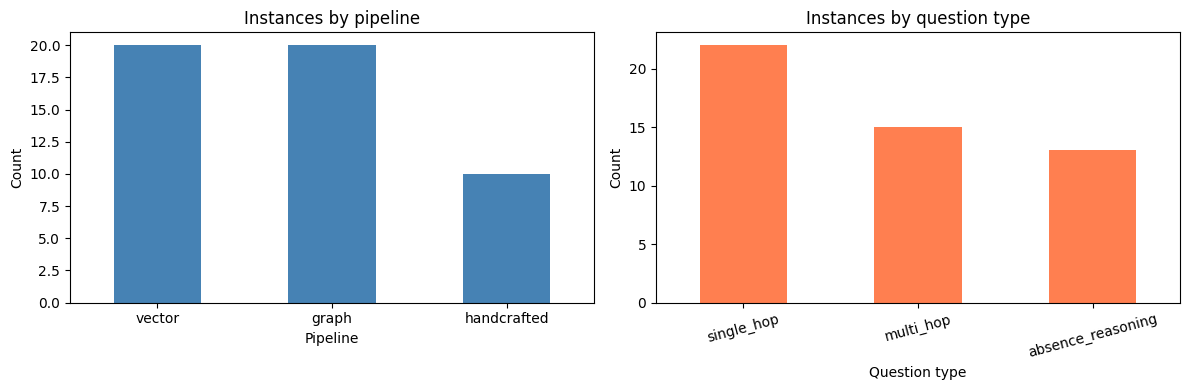

   pipeline     question_type  count
      graph absence_reasoning      5
      graph         multi_hop      6
      graph        single_hop      9
handcrafted absence_reasoning      3
handcrafted         multi_hop      3
handcrafted        single_hop      4
     vector absence_reasoning      5
     vector         multi_hop      6
     vector        single_hop      9


In [6]:
all_instances = vector_answers + graph_answers + HANDCRAFTED
df = pd.DataFrame(all_instances)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["pipeline"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Instances by pipeline")
axes[0].set_xlabel("Pipeline")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df["question_type"].value_counts().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Instances by question type")
axes[1].set_xlabel("Question type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_corpus_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(df.groupby(["pipeline", "question_type"]).size().rename("count").reset_index().to_string(index=False))

## 3. Synthetic human scores

Human annotation follows the scoring rubric for each RAG Triad dimension.
Good answers score high, mediocre answers mid-range, bad answers low.
The handcrafted instances provide ground-truth quality signal for calibration in notebook 05.

In [7]:
import numpy as np

rng = np.random.default_rng(42)

QUALITY_SCORES = {
    "good":     {"context_relevance": (0.80, 0.10), "groundedness": (0.85, 0.08), "answer_relevance": (0.88, 0.07)},
    "mediocre": {"context_relevance": (0.55, 0.12), "groundedness": (0.50, 0.12), "answer_relevance": (0.52, 0.10)},
    "bad":      {"context_relevance": (0.30, 0.10), "groundedness": (0.20, 0.10), "answer_relevance": (0.25, 0.10)},
}

# Absence-reasoning instances are harder — human scores are lower even for good answers
ABSENCE_PENALTY = {"context_relevance": -0.05, "groundedness": -0.02, "answer_relevance": 0.0}

def human_score(instance: dict, metric: str) -> float:
    quality = "good"
    iid = instance["id"]
    if iid.endswith("_mediocre"):
        quality = "mediocre"
    elif iid.endswith("_bad"):
        quality = "bad"
    mu, sigma = QUALITY_SCORES[quality][metric]
    if instance["question_type"] == "absence_reasoning":
        mu += ABSENCE_PENALTY[metric]
    return float(np.clip(rng.normal(mu, sigma), 0.0, 1.0))


METRICS = ["context_relevance", "groundedness", "answer_relevance"]

rows = []
for instance in sorted(all_instances, key=lambda x: x["id"]):
    row = {"id": instance["id"]}
    for metric in METRICS:
        row[metric] = round(human_score(instance, metric), 4)
    rows.append(row)

human_df = pd.DataFrame(rows)
print(f"Human scores: {len(human_df)} instances")
human_df.describe()

Human scores: 50 instances


,context_relevance,groundedness,answer_relevance
count,50.000000,50.000000,50.000000
mean,0.741332,0.773154,0.818906
std,0.162114,0.187658,0.168536
min,0.214700,0.096000,0.231500
25%,0.686975,0.743725,0.816525
50%,0.768150,0.818600,0.878700
75%,0.861600,0.888875,0.908750
max,1.000000,1.000000,0.970900


Saved 50 human scores to /workspaces/llm_judge_benchmark/data/human/human_scores.csv


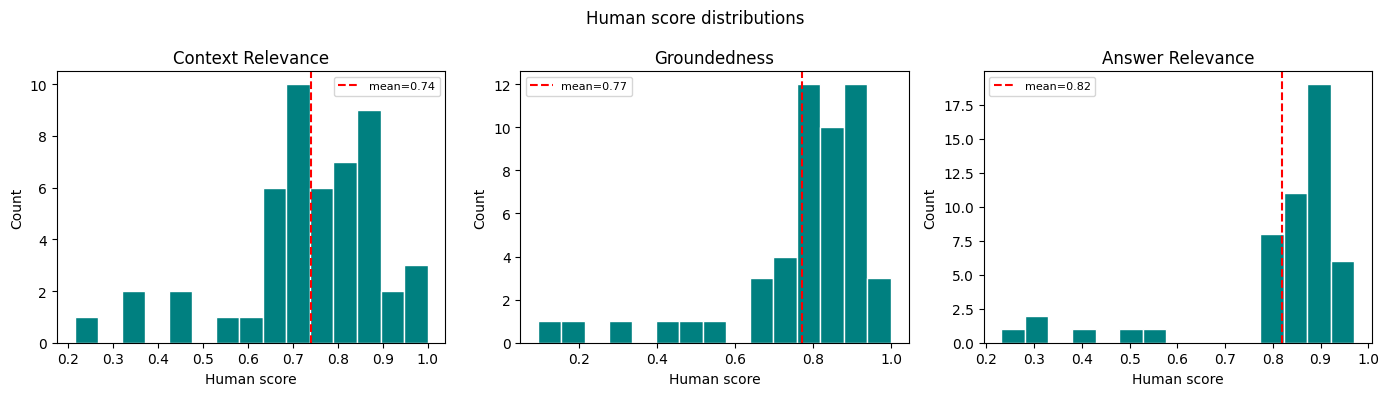

In [8]:
(ROOT / "data" / "human").mkdir(parents=True, exist_ok=True)
human_path = ROOT / "data" / "human" / "human_scores.csv"
human_df.to_csv(human_path, index=False)
print(f"Saved {len(human_df)} human scores to {human_path}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, METRICS):
    ax.hist(human_df[metric], bins=15, color="teal", edgecolor="white")
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Human score")
    ax.set_ylabel("Count")
    ax.axvline(human_df[metric].mean(), color="red", linestyle="--", label=f"mean={human_df[metric].mean():.2f}")
    ax.legend(fontsize=8)
fig.suptitle("Human score distributions")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_human_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Schema validation

Confirm every instance matches the expected data contract before scoring.

In [9]:
REQUIRED_FIELDS = {"id", "question", "context", "answer", "pipeline", "question_type"}

errors = []
for inst in all_instances:
    missing = REQUIRED_FIELDS - set(inst.keys())
    if missing:
        errors.append(f"{inst['id']}: missing {missing}")
    if not isinstance(inst["context"], list):
        errors.append(f"{inst['id']}: context must be a list")

if errors:
    for e in errors:
        print(f"ERROR: {e}")
else:
    print(f"All {len(all_instances)} instances pass schema validation.")
    print("\nPipeline counts:", dict(pd.Series([i['pipeline'] for i in all_instances]).value_counts()))
    print("Question type counts:", dict(pd.Series([i['question_type'] for i in all_instances]).value_counts()))

All 50 instances pass schema validation.

Pipeline counts: {'vector': np.int64(20), 'graph': np.int64(20), 'handcrafted': np.int64(10)}
Question type counts: {'single_hop': np.int64(22), 'multi_hop': np.int64(15), 'absence_reasoning': np.int64(13)}


---
**Next:** Run `02_judge_scoring.ipynb` to score all instances with the three judge models. Requires Ollama running with models pulled (`make setup`).